# cal the material demand (inflow, outflow, stock) for ESS

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 9

import time
start_time = time.time()
print(time.ctime())

import warnings
warnings.filterwarnings('ignore')

from dynamic_stock_model import DynamicStockModel

file_path = r'C:\Users\xmuxi\Desktop\2-UCAS\4-Co-Ni-Cu\Data\Sector_ESS\5Regions\\'

Sun Aug  2 15:20:59 2026


In [2]:
ESS_Scenarios = ['STEPS','APS','NZES']

Lifetime_Scenarios = ['Constant','Longer']

Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Battery_Scenarios = ['Baseline','NMC', 'NMA', 'LFP/LMFP', 'Na-ion','Optimized']

Cathodes =['LFP','LMFP','LNO','LMO','LNMO',
           'NCA-85','NCA-90','NCA-92','NCA-95','NMCA',
           'NMC-111','NMC-532','NMC-622','NMC-721','NMC-811','NMC-955',
           'LMR-NMC','Na-ion']

cathode_color_dict = {'LFP': '#7F7F7F',
                      'LMFP':'#BFBFBF',

                      'LNO':'#A7D3D4',
                      'LMO':'#42B7B9',
                      'LNMO':'#009B9E',
                      
                      'NCA-85':'#FFE285',
                      'NCA-90':'#FFD757',
                      'NCA-92':'#FFC611',
                      'NCA-95':'#E2AC00',
                      
                      'NMCA':'#7654A3',
                      
                      'NMC-111':'#C7F2FF',
                      'NMC-532':'#8FE4FF',
                      'NMC-622':'#56D7FF',
                      'NMC-721':'#00AEE5',
                      'NMC-811':'#0082AC',
                      'NMC-955':'#005772',
                      
                      'LMR-NMC':'#002060',
                      'Na-ion':'#F03B20'}
Cathode_Colors = [cathode_color_dict[ca] for ca in Cathodes]

Materials = ['Copper','Nickel','Cobalt']

## Layer: ESS

In [3]:
## ESS power capacity: GW

df_ESS_power = pd.read_excel(file_path + 'Input_ESS_IEA.xlsx', sheet_name='ESS_Power_Capacity', index_col=[0], header=[2,3])
df_ESS_power.drop(index=['World'], inplace=True)
df_ESS_power

Regions Historical                                            STEPS          \
              2010  2015  2021   2022       2023       2024    2030    2035   
China         0.02  0.21  5.73  13.08  15.574862  25.414329  245.14  472.34   
Japan         0.10  0.50  2.03   2.43   2.893495   4.721469    5.74    8.51   
EU            0.02  0.30  4.67   8.44  10.049835  16.398848   30.43   67.40   
USA           0.40  0.80  7.27  12.06  14.360309  23.432477  162.65  288.17   
RoW           0.17  0.36  7.50   9.34  11.121499  18.147540  107.86  210.81   

Regions                  ...     APS                                    \
           2040    2045  ...    2030    2035    2040     2045     2050   
China    663.75  811.86  ...  258.74  474.80  664.81   812.31   861.08   
Japan     10.08   11.06  ...    6.56   14.03   18.02    22.30    27.93   
EU       116.29  172.92  ...   67.43  123.38  182.66   246.78   320.73   
USA      387.73  454.83  ...  212.25  351.60  437.35   482.73   510.44   
RoW      353.53  509.98  ...  179.75  413.28  725.85  1061.27  1401.12   

Regions        NZES                                                     
               2030        2035         2040         2045         2050  
China    363.613367  671.889460   931.076123  1100.790369  1158.346124  
Japan      9.218921   19.853852    25.237273    30.219529    37.572127  
EU        94.760954  174.595033   255.818000   334.420415   431.453933  
USA      298.279884  497.549145   612.515068   654.164709   686.656519  
RoW      252.606874  584.832510  1016.563535  1438.164979  1884.821296  

[5 rows x 21 columns]

In [4]:
## Linear interpolate

def linear_interpolate_ess(df_raw):
    
    df_full = pd.DataFrame(index=np.arange(2010,2051), 
                          columns=pd.MultiIndex.from_product([ESS_Scenarios, Regions], 
                                                             names=['Scenario','Region']))
    
    df_his = df_raw['Historical']
    for sce in ESS_Scenarios:
        for region in Regions:
            for year in df_his.columns:
                df_full.at[year, (sce, region)] = df_his.at[region, year]
    
    for sce in ESS_Scenarios:
        df_future = df_raw[sce]
        for region in Regions:
            for year in df_future.columns:
                df_full.at[year, (sce, region)] = df_future.at[region, year]
            
    # interpolate
    for col in df_full.columns:
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce')
    df_full.interpolate(method='linear', limit_area='inside', inplace=True)
    
    return df_full


df_ess_power_stock = linear_interpolate_ess(df_ESS_power)
df_ess_power_stock.tail(2)

Scenario   STEPS                                        APS                  \
Region     China   Japan       EU      USA     RoW    China   Japan      EU   
2049      903.54  11.116  224.832  497.598  636.62  851.326  26.804  305.94   
2050      926.46  11.130  237.810  508.290  668.28  861.080  27.930  320.73   

Scenario                           NZES                                     \
Region        USA      RoW        China      Japan          EU         USA   
2049      504.898  1333.15  1146.834973  36.101607  412.047229  680.158157   
2050      510.440  1401.12  1158.346124  37.572127  431.453933  686.656519   

Scenario               
Region            RoW  
2049      1795.490033  
2050      1884.821296

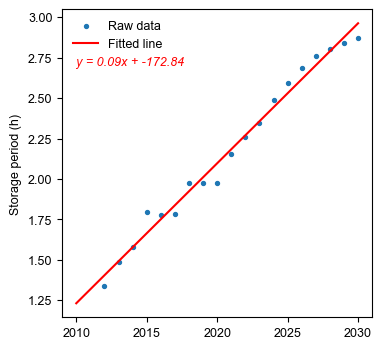

,StoragePeriod
2010,1.33549
2011,1.33549
2012,1.33549
2013,1.485107
2014,1.576868
2015,1.798104
2016,1.779249
2017,1.782699
2018,1.976189
2019,1.977308


In [5]:
## Storage Period

def fullfill_storage_period(df):
    
    df_full = pd.DataFrame(index=np.arange(2010,2051), columns=['StoragePeriod'])
    
    # 线性拟合
    slope, intercept, r_value, p_value, std_err = stats.linregress(df.index, df.StoragePeriod)
    
    for year in df_full.index:
        if year in df.index:
            df_full.at[year, 'StoragePeriod'] = df.at[year, 'StoragePeriod']
        elif year < 2012:
            df_full.at[year, 'StoragePeriod'] = df.at[2012, 'StoragePeriod']
        else:
            #df_full.at[year, 'StoragePeriod'] = slope * year + intercept
            df_full.at[year, 'StoragePeriod'] = df.at[2030, 'StoragePeriod']
            
    # Plot
    fig, ax = plt.subplots(figsize = (4, 4))
    
    ax.scatter(df.index, df.StoragePeriod, s=8, label='Raw data')
    ax.plot(np.arange(2010,2031), slope * np.arange(2010,2031) + intercept, color='red', label='Fitted line')
    
    ax.text(2010, 2.7, f'y = {slope:.2f}x + {intercept:.2f}', color='red', style='italic')
    ax.set_ylabel('Storage period (h)')
    plt.legend(frameon=False)
    plt.show()
    
    return df_full


df_period = pd.read_excel(file_path + 'Input_ESS_IEA.xlsx', sheet_name='Storage_Period', index_col=[0], header=[2])
df_period = fullfill_storage_period(df_period)
df_period

In [6]:
def convert_power_to_energy(df_power, df_h):
    ## from GW to GWh
    
    df_energy = df_power.copy()
    
    for col in df_power.columns:
        df_energy[col] = df_power[col] * df_h.StoragePeriod
        
    return df_energy


## Unit: GWh
df_ess_energy_stock = convert_power_to_energy(df_ess_power_stock, df_period)
df_ess_energy_stock.tail(2)

Scenario        STEPS                                                   \
Region          China      Japan          EU          USA          RoW   
2049      2596.704923  31.946535  646.149989  1430.058632  1829.597238   
2050      2662.575252   31.98677   683.44777  1460.786623  1920.585659   

Scenario          APS                                                   \
Region          China      Japan          EU          USA          RoW   
2049      2446.645877  77.032648  879.248184  1451.038274  3831.371238   
2050      2474.678128  80.268686  921.753514  1466.965559  4026.711825   

Scenario         NZES                                                     
Region          China       Japan           EU          USA          RoW  
2049      3295.916087  103.753261  1184.192254  1954.722575  5160.101167  
2050      3328.998256  107.979423  1239.965637  1973.398371  5416.832392

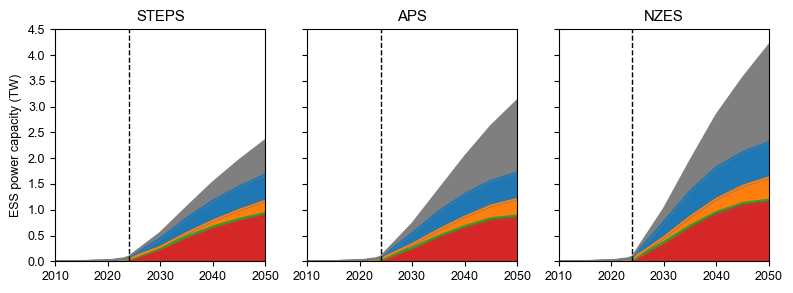

In [7]:
def plot_ess_stock_by_region(df_power):
    
    ## from GW to TW
    df_power = df_power/1e3
    
    fig, axes = plt.subplots(1,3, figsize = (8,3), sharex=True, sharey=True)

    for i, e_sce in enumerate(ESS_Scenarios):
        df_p = df_power[e_sce]
        df_p.plot.area(ax=axes[i], y=Regions, legend=False, color=Region_Colors)
        axes[i].set_ylabel('ESS power capacity (TW)')
        axes[i].set_title(e_sce)
        
    for i, ax in enumerate(axes):
        ax.set_xlim(2010,2050)
        ax.set_ylim(0,4.5)
        ax.axvline(x=2024, color="black", linestyle="--", lw=1)
        
    #plt.legend(frameon=False)
    
    plt.tight_layout()
    plt.savefig(file_path + 'ESS_Power_Stock.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
     
    
plot_ess_stock_by_region(df_ess_power_stock)

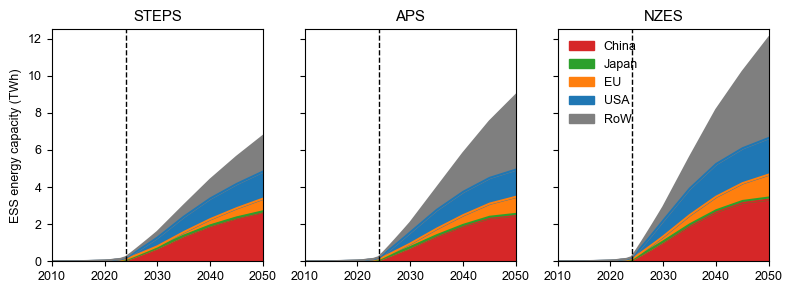

In [8]:
def plot_ess_stock_by_region(df_energy):
    
    ## from GW to TW
    df_energy = df_energy/1e3
    
    fig, axes = plt.subplots(1,3, figsize = (8,3), sharex=True, sharey=True)

    for i, e_sce in enumerate(ESS_Scenarios):
        df_p = df_energy[e_sce]
        df_p.plot.area(ax=axes[i], y=Regions, legend=False, color=Region_Colors)
        axes[i].set_ylabel('ESS energy capacity (TWh)')
        axes[i].set_title(e_sce)
        axes[i].axvline(x=2024, color="black", linestyle="--", lw=1)
        
    for i, ax in enumerate(axes):
        ax.set_xlim(2010,2050)
        ax.set_ylim(0,12.5)
        
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(file_path + 'ESS_Energy_Stock.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
     
    
plot_ess_stock_by_region(df_ess_energy_stock)

In [9]:
df_lifetime = pd.read_excel(file_path + 'Input_ESS_IEA.xlsx', sheet_name='Lifetime', index_col=[0], header=[2])
df_lifetime.tail(2)

,Constant,Longer
Year,,
2049,10,19.615385
2050,10,20.000000


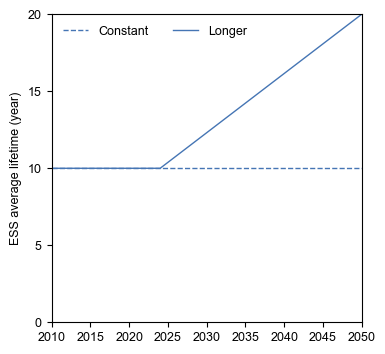

In [10]:
def plot_lifetime(df):
    year_min = 2010
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    
    ax.plot(df.index, df['Constant'], label='Constant', color='#4575B4', lw=1, linestyle='--')
    ax.plot(df.index, df['Longer'], label='Longer', color='#4575B4', lw=1)
    
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(year_min,2051,5))
    ax.set_ylim(0,20)
    ax.set_yticks(np.arange(0,21,5))
    ax.set_ylabel('ESS average lifetime (year)')
    ax.legend(frameon=False, ncol=2)
    plt.savefig(file_path + 'ESS_Lifetime.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
plot_lifetime(df_lifetime)

In [11]:
def cal_ess_stocks_flows(df_stock, df_lt):
    
    df_i = pd.DataFrame(index=df_stock.index, 
                        columns=pd.MultiIndex.from_product([ESS_Scenarios,Regions,Lifetime_Scenarios], names=['ESS Scenario','Region','Lifetime']))
    df_o = df_i.copy()
    df_s = df_i.copy()
    
    for e_sce in ESS_Scenarios:
        for r in Regions:
            for lt in Lifetime_Scenarios:
                
                df_s[(e_sce,r,lt)] = df_stock[e_sce,r]
                
                ## stock-driven
                DSM = DynamicStockModel(t=list(df_s.index), 
                                       s = list(df_s[(e_sce,r,lt)]), 
                                       lt = {'Type': 'Normal', 
                                             'Mean': list(df_lt[lt]), 
                                             'StdDev': list(0.3 * df_lt[lt])})
                DSM.compute_stock_driven_model()
                DSM.compute_outflow_total()

                ## fill in 
                df_i[(e_sce,r,lt)] = DSM.i
                df_o[(e_sce,r,lt)] = DSM.o
        
    return df_i, df_o, df_s


df_ess_energy_inflow, df_ess_energy_outflow, df_ess_energy_stock = cal_ess_stocks_flows(df_ess_energy_stock, df_lifetime)
df_ess_energy_inflow.tail(2)

ESS Scenario       STEPS                                             \
Region             China                 Japan                   EU   
Lifetime        Constant      Longer  Constant    Longer   Constant   
2049          279.090337  185.981274  2.973961  1.970876  80.275346   
2050          286.480386  188.550163  2.991099  1.951730  83.396462   

ESS Scenario                                                             ...  \
Region                          USA                     RoW              ...   
Lifetime         Longer    Constant      Longer    Constant      Longer  ...   
2049          59.605569  151.917721   99.992927  219.885991  155.552580  ...   
2050          60.756094  155.150067  101.123691  228.546363  159.207144  ...   

ESS Scenario        NZES                                               \
Region             China                  Japan                    EU   
Lifetime        Constant      Longer   Constant    Longer    Constant   
2049          326.385634  198.829007  11.953225  9.159520  142.154528   
2050          333.974494  202.080685  12.215561  9.131071  146.545989   

ESS Scenario                                                            
Region                           USA                   RoW              
Lifetime          Longer    Constant     Longer   Constant      Longer  
2049          102.232890  197.974487  125.48183  623.21955  444.073528  
2050          103.822115  199.682992  125.64440  646.04172  454.105138  

[2 rows x 30 columns]

## Layer: Battery

In [12]:
## Cathode market share

df_ESS_Battery_share = pd.read_excel(file_path + 'Input_ESS_IEA.xlsx', sheet_name='Battery_Share', index_col=[0], header=[2,3])
df_ESS_Battery_share.fillna(value=0.0, inplace=True)
df_ESS_Battery_share.head(2)

Scenario Baseline                                                           \
Cathode       LFP LMFP LNO       LMO LNMO NCA-85 NCA-90 NCA-92 NCA-95 NMCA   
2010          0.1  0.0   0  0.427287    0    0.3    0.0    0.0    0.0  0.0   
2011          0.1  0.0   0  0.427287    0    0.3    0.0    0.0    0.0  0.0   

Scenario  ... Optimized                                                 \
Cathode   ...    NCA-95 NMCA   NMC-111 NMC-532 NMC-622 NMC-721 NMC-811   
2010      ...       0.0  0.0  0.172713     0.0     0.0     0.0     0.0   
2011      ...       0.0  0.0  0.172713     0.0     0.0     0.0     0.0   

Scenario                         
Cathode  NMC-955 LMR-NMC Na-ion  
2010         0.0     0.0      0  
2011         0.0     0.0      0  

[2 rows x 108 columns]

In [13]:
def cal_battery_inflow(df_energy, df_share):
    
    df_battery_inflow = pd.DataFrame(index=df_share.index, 
                                     columns = pd.MultiIndex.from_product([ESS_Scenarios, Lifetime_Scenarios, Battery_Scenarios, Regions, Cathodes], 
                                                                          names=['ESS Scenario','Lifetime','Battery Scenario','Region','Cathode']))
    
    for e_sce in ESS_Scenarios:
        for lt in Lifetime_Scenarios:
            for b_sce in Battery_Scenarios:
                for region in Regions:
                    for cathode in Cathodes:
                        df_battery_inflow[(e_sce,lt,b_sce,region,cathode)] = df_energy[(e_sce,region,lt)] * df_share[(b_sce, cathode)]
    
    return df_battery_inflow


## Unit: GWh
df_ess_battery_inflow = cal_battery_inflow(df_ess_energy_inflow, df_ESS_Battery_share)
df_ess_battery_inflow.head(3)

ESS Scenario         STEPS                                                   \
Lifetime          Constant                                                    
Battery Scenario  Baseline                                                    
Region               China                                                    
Cathode                LFP LMFP  LNO       LMO LNMO    NCA-85 NCA-90 NCA-92   
2010              0.002672  0.0  0.0  0.011418  0.0  0.008016    0.0    0.0   
2011              0.005080  0.0  0.0  0.021704  0.0  0.015239    0.0    0.0   
2012              0.015265  0.0  0.0  0.021742  0.0  0.005361    0.0    0.0   

ESS Scenario                  ...      NZES                                 \
Lifetime                      ...    Longer                                  
Battery Scenario              ... Optimized                                  
Region                        ...       RoW                                  
Cathode          NCA-95 NMCA  ...    NCA-95 NMCA   NMC-111 NMC-532 NMC-622   
2010                0.0  0.0  ...       0.0  0.0  0.039228     0.0     0.0   
2011                0.0  0.0  ...       0.0  0.0  0.008805     0.0     0.0   
2012                0.0  0.0  ...       0.0  0.0  0.008599     0.0     0.0   

ESS Scenario                                             
Lifetime                                                 
Battery Scenario                                         
Region                                                   
Cathode          NMC-721 NMC-811 NMC-955 LMR-NMC Na-ion  
2010                 0.0     0.0     0.0     0.0    0.0  
2011                 0.0     0.0     0.0     0.0    0.0  
2012                 0.0     0.0     0.0     0.0    0.0  

[3 rows x 3240 columns]

In [14]:
def cal_battery_stocks_flows(df_i, df_lt):
    
    df_s = df_i.copy()
    df_o = df_i.copy()
    
    for e_sce in ESS_Scenarios:
        for lt in Lifetime_Scenarios:
            for b_sce in Battery_Scenarios:
                for region in Regions:
                    for cathode in Cathodes:
                        ## inflow-driven
                        DSM = DynamicStockModel(t = df_i.index, 
                                                i = df_i[(e_sce,lt,b_sce,region,cathode)], 
                                                lt = {'Type': 'Normal',
                                                      'Mean': list(df_lt[lt]), 
                                                      'StdDev': list(0.3 * df_lt[lt])})
                        DSM.compute_s_c_inflow_driven()
                        DSM.compute_stock_total()
                        DSM.compute_o_c_from_s_c()
                        DSM.compute_outflow_total()
        
                        ## fill in 
                        df_o[(e_sce,lt,b_sce,region,cathode)] = DSM.o
                        df_s[(e_sce,lt,b_sce,region,cathode)] = DSM.s
        
    return df_s, df_o


df_ess_battery_stock,  df_ess_battery_outflow = cal_battery_stocks_flows(df_ess_battery_inflow, df_lifetime)
df_ess_battery_stock.head(2)

ESS Scenario         STEPS                                                   \
Lifetime          Constant                                                    
Battery Scenario  Baseline                                                    
Region               China                                                    
Cathode                LFP LMFP  LNO       LMO LNMO    NCA-85 NCA-90 NCA-92   
2010              0.002671  0.0  0.0  0.011413  0.0  0.008013    0.0    0.0   
2011              0.007746  0.0  0.0  0.033097  0.0  0.023238    0.0    0.0   

ESS Scenario                  ...      NZES                                 \
Lifetime                      ...    Longer                                  
Battery Scenario              ... Optimized                                  
Region                        ...       RoW                                  
Cathode          NCA-95 NMCA  ...    NCA-95 NMCA   NMC-111 NMC-532 NMC-622   
2010                0.0  0.0  ...       0.0  0.0  0.039212     0.0     0.0   
2011                0.0  0.0  ...       0.0  0.0  0.047977     0.0     0.0   

ESS Scenario                                             
Lifetime                                                 
Battery Scenario                                         
Region                                                   
Cathode          NMC-721 NMC-811 NMC-955 LMR-NMC Na-ion  
2010                 0.0     0.0     0.0     0.0    0.0  
2011                 0.0     0.0     0.0     0.0    0.0  

[2 rows x 3240 columns]

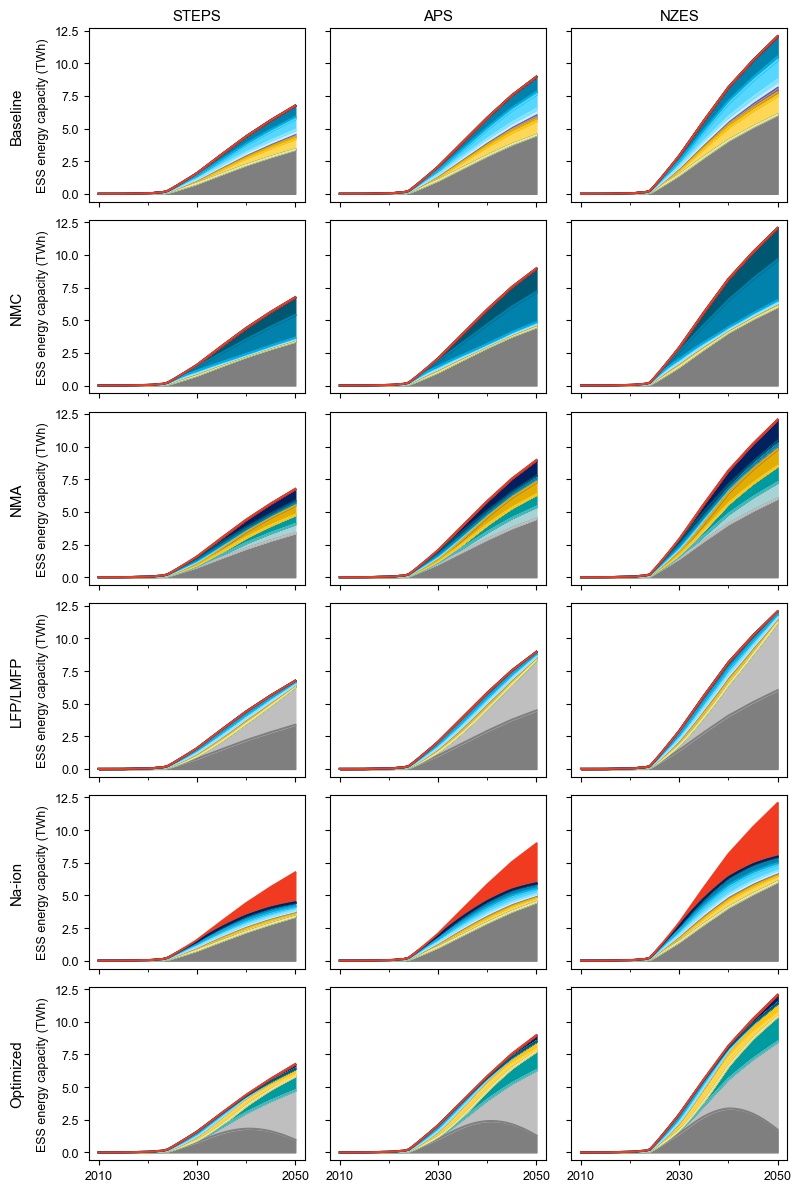

In [15]:
def plot_battery_stock_by_cathode(df):
    
    ## Global
    df = df / 1e3 # from GWh to TWh
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df.Lifetime=='Constant']
    df = df.groupby(['ESS Scenario','Battery Scenario','Cathode']).sum(numeric_only=True)
    df = df.T
    
    fig, axes = plt.subplots(len(Battery_Scenarios), len(ESS_Scenarios), figsize = (8, 12), sharex=True, sharey=True)
                
    for i, b_sce in enumerate(Battery_Scenarios):
        for j, e_sce in enumerate(ESS_Scenarios):
            
            df_c = df[(e_sce,b_sce)]
            df_c.plot.area(ax=axes[i,j], y=Cathodes, color=Cathode_Colors, legend=False)
                
            #axes[i,j].set_xlim(2010,2050)
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylabel('ESS energy capacity (TWh)')
            
            if i == 0:
                axes[i,j].set_title(e_sce)
            if j == 0:
                axes[i,j].annotate(b_sce, xy=(-0.3, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
    plt.tight_layout()        
    plt.show()
    

plot_battery_stock_by_cathode(df_ess_battery_stock)

## Layer: Material

In [16]:
## Material intensity: kg metal / kWh  = kt metal / GWh

df_material_intensity = pd.read_excel(file_path + 'Input_ESS_IEA.xlsx', sheet_name='Battery_Material_intensity', index_col=[0], header=[2])
df_material_intensity.fillna(value=0, inplace=True)
df_material_intensity

,Copper,Nickel,Cobalt,Manganese
Cathodes,,,,
LFP,0.480,0.000,0.000,0.00
LMFP,0.480,0.000,0.000,0.31
LNO,0.279,0.780,0.000,0.00
LMO,0.450,0.000,0.000,1.27
LNMO,0.232,0.250,0.000,0.71
NCA-85,0.270,0.730,0.090,0.00
NCA-90,0.270,0.740,0.040,0.00
NCA-92,0.270,0.720,0.020,0.00
NCA-95,0.270,0.850,0.050,0.00


In [17]:
def cal_material_inflow(df_battery, df_intensity):
    
    df_material_inflow = pd.DataFrame(index=df_battery.index, 
                                     columns = pd.MultiIndex.from_product([Materials,ESS_Scenarios,Lifetime_Scenarios,Battery_Scenarios,Regions,Cathodes], 
                                                                          names=['Material','ESS Scenario','Lifetime','Battery Scenario','Region','Cathode']))
    
    for material in Materials:
        for e_sce in ESS_Scenarios:
            for lt in Lifetime_Scenarios:
                for b_sce in Battery_Scenarios:
                    for region in Regions:
                        for cathode in Cathodes:
                            df_material_inflow[(material, e_sce, lt, b_sce, region, cathode)] = df_battery[(e_sce, lt, b_sce, region, cathode)] * df_intensity.at[cathode, material]

    return df_material_inflow


## Unit: kt
df_ess_material_inflow = cal_material_inflow(df_ess_battery_inflow, df_material_intensity)
df_ess_material_inflow.head(2)

Material            Copper                                                   \
ESS Scenario         STEPS                                                    
Lifetime          Constant                                                    
Battery Scenario  Baseline                                                    
Region               China                                                    
Cathode                LFP LMFP  LNO       LMO LNMO    NCA-85 NCA-90 NCA-92   
2010              0.001283  0.0  0.0  0.005138  0.0  0.002164    0.0    0.0   
2011              0.002438  0.0  0.0  0.009767  0.0  0.004114    0.0    0.0   

Material                      ...    Cobalt                                 \
ESS Scenario                  ...      NZES                                  
Lifetime                      ...    Longer                                  
Battery Scenario              ... Optimized                                  
Region                        ...       RoW                                  
Cathode          NCA-95 NMCA  ...    NCA-95 NMCA   NMC-111 NMC-532 NMC-622   
2010                0.0  0.0  ...       0.0  0.0  0.015456     0.0     0.0   
2011                0.0  0.0  ...       0.0  0.0  0.003469     0.0     0.0   

Material                                                 
ESS Scenario                                             
Lifetime                                                 
Battery Scenario                                         
Region                                                   
Cathode          NMC-721 NMC-811 NMC-955 LMR-NMC Na-ion  
2010                 0.0     0.0     0.0     0.0    0.0  
2011                 0.0     0.0     0.0     0.0    0.0  

[2 rows x 9720 columns]

In [18]:
def cal_material_stocks_flows(df_i, df_lt):
    
    df_s = df_i.copy()
    df_o = df_i.copy()
    
    for material in Materials:
        for e_sce in ESS_Scenarios:
            for lt in Lifetime_Scenarios:
                for b_sce in Battery_Scenarios:
                    for region in Regions:
                        for cathode in Cathodes:
                            ## inflow-driven
                            DSM = DynamicStockModel(t = df_i.index, 
                                                    i = df_i[(material,e_sce,lt,b_sce,region,cathode)], 
                                                    lt = {'Type': 'Normal',
                                                          'Mean': list(df_lt[lt]), 
                                                          'StdDev': list(0.3 * df_lt[lt])})
                            DSM.compute_s_c_inflow_driven()
                            DSM.compute_stock_total()
                            DSM.compute_o_c_from_s_c()
                            DSM.compute_outflow_total()

                            ## fill in 
                            df_o[(material,e_sce,lt,b_sce,region,cathode)] = DSM.o
                            df_s[(material,e_sce,lt,b_sce,region,cathode)] = DSM.s
        
    return df_s, df_o


df_ess_material_stock,  df_ess_material_outflow = cal_material_stocks_flows(df_ess_material_inflow, df_lifetime)
df_ess_material_stock.tail(2)

Material              Copper                                                  \
ESS Scenario           STEPS                                                   
Lifetime            Constant                                                   
Battery Scenario    Baseline                                                   
Region                 China                                                   
Cathode                  LFP      LMFP  LNO           LMO LNMO        NCA-85   
2049              623.209182  3.285171  0.0  2.134482e-12  0.0  2.575741e-12   
2050              639.018061  3.368506  0.0  2.530077e-13  0.0  3.061911e-13   

Material                                                         ...  \
ESS Scenario                                                     ...   
Lifetime                                                         ...   
Battery Scenario                                                 ...   
Region                                                           ...   
Cathode              NCA-90        NCA-92     NCA-95       NMCA  ...   
2049              84.182517  4.050633e-12  15.741446  22.585553  ...   
2050              86.317966  4.417979e-13  16.140758  23.158479  ...   

Material            Cobalt                                              \
ESS Scenario          NZES                                               
Lifetime            Longer                                               
Battery Scenario Optimized                                               
Region                 RoW                                               
Cathode             NCA-95      NMCA       NMC-111   NMC-532   NMC-622   
2049              0.000050  0.014219  3.734354e-06  0.000016  0.591415   
2050              0.000018  0.007715  8.153234e-07  0.000004  0.367790   

Material                                                              
ESS Scenario                                                          
Lifetime                                                              
Battery Scenario                                                      
Region                                                                
Cathode            NMC-721   NMC-811       NMC-955    LMR-NMC Na-ion  
2049              0.665509  0.035781  2.260579e-15  20.542713    0.0  
2050              0.514541  0.018351  2.404879e-16  22.971995    0.0  

[2 rows x 9720 columns]

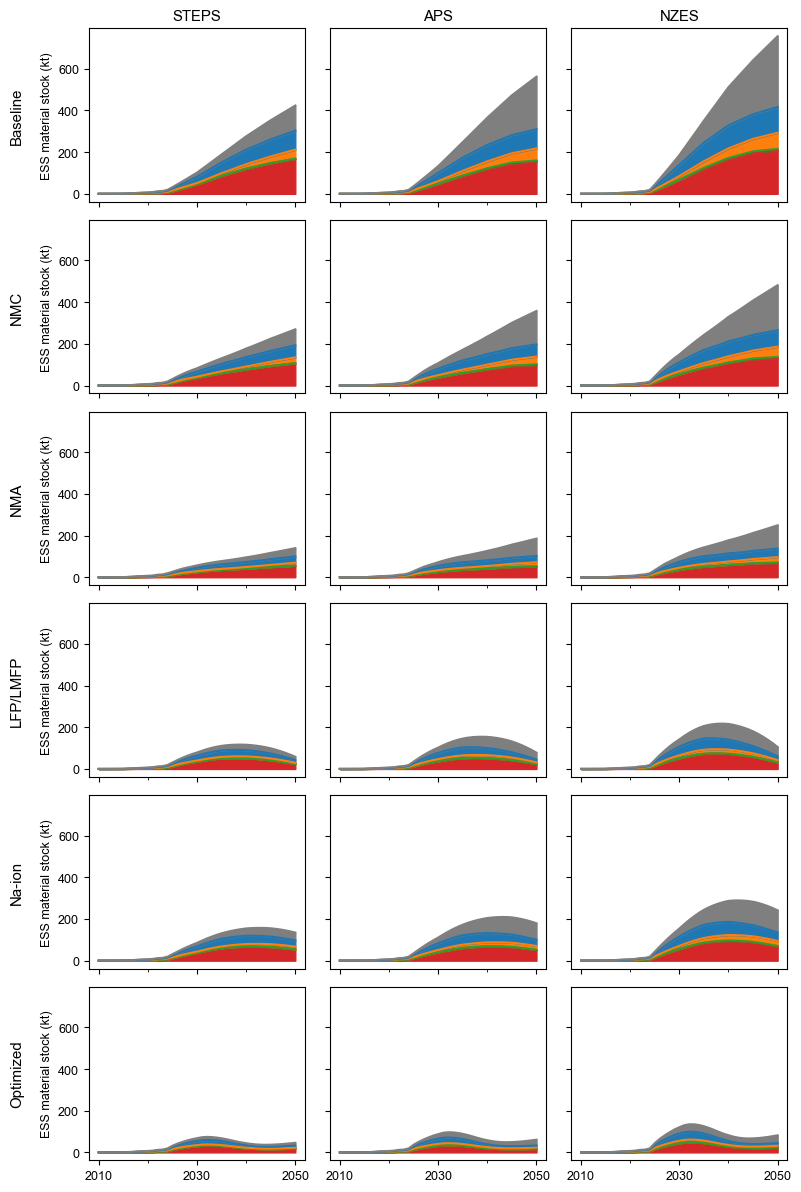

In [19]:
def plot_material_stock_by_region(df, material):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df.Material==material]
    df = df[df.Lifetime=='Constant']
    df = df.groupby(['ESS Scenario','Battery Scenario','Region']).sum(numeric_only=True)
    df = df.T
    
    fig, axes = plt.subplots(len(Battery_Scenarios), len(ESS_Scenarios), figsize = (8, 12), sharex=True, sharey=True)

    for i, b_sce in enumerate(Battery_Scenarios):
        for j, e_sce in enumerate(ESS_Scenarios):
            
            df_c = df[(e_sce,b_sce)]
            df_c.plot.area(ax=axes[i,j], y=Regions, color=Region_Colors, legend=False)
        
            #axes[i,j].set_xlim(2010,2050)
            #axes[i,j].axvline(2022, color='k', linestyle='--', lw=1)
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylabel('ESS material stock (kt)')

            if i == 0:
                axes[i,j].set_title(e_sce)
            if j == 0:
                axes[i,j].annotate(b_sce, xy=(-0.3, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
    
    plt.tight_layout()
    plt.show()
    
    
#plot_material_stock_by_region(df_ess_material_stock, 'Copper')
#plot_material_stock_by_region(df_ess_material_stock, 'Nickel')
plot_material_stock_by_region(df_ess_material_stock, 'Cobalt')
#plot_material_stock_by_region(df_ess_material_inflow, 'Cobalt')

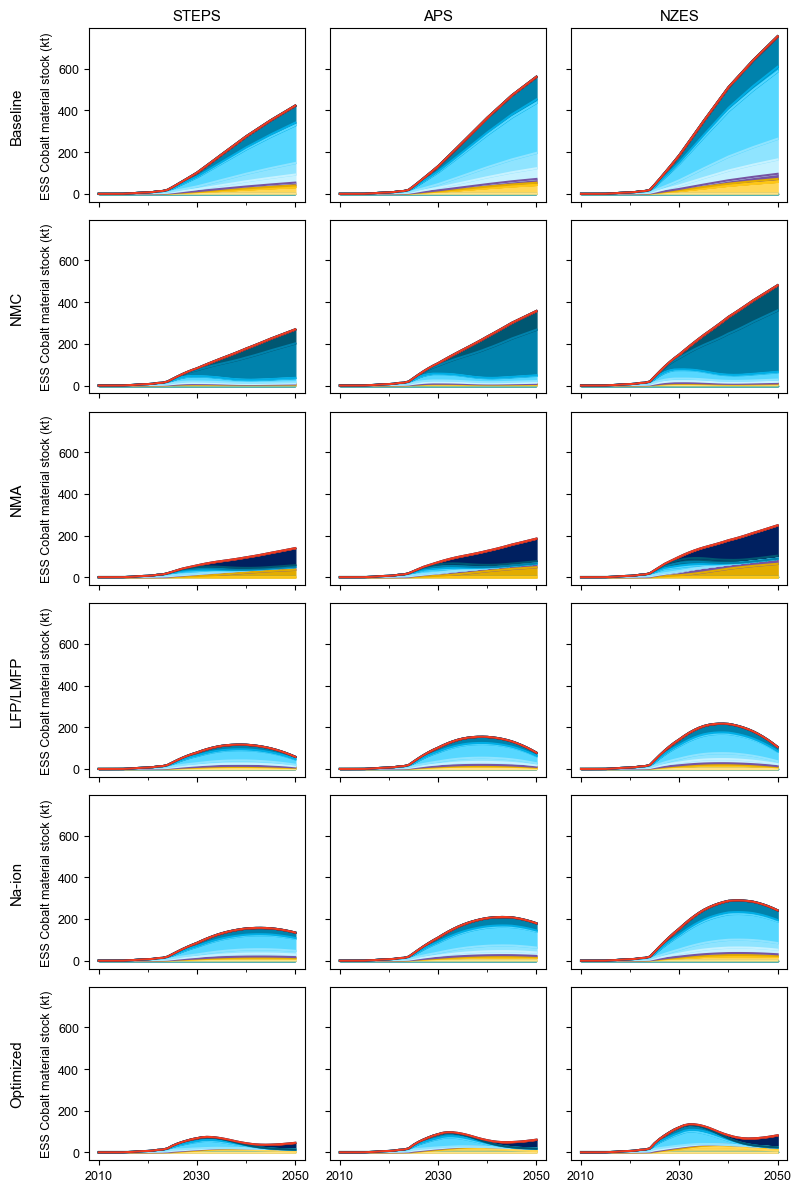

In [20]:
def plot_material_stock_by_cathode(df, material):
    
    ## World
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df.Material==material]
    df = df[df.Lifetime=='Constant']
    df = df.groupby(['ESS Scenario','Battery Scenario','Cathode']).sum(numeric_only=True)
    df = df.T
    
    fig, axes = plt.subplots(len(Battery_Scenarios), len(ESS_Scenarios), figsize = (8, 12), sharex=True, sharey=True)
    
    for i, b_sce in enumerate(Battery_Scenarios):
        for j, e_sce in enumerate(ESS_Scenarios):
            
            df_c = df[e_sce, b_sce]
            df_c.plot.area(ax=axes[i,j], y=Cathodes, color=Cathode_Colors, legend=False)
        
            #axes[i,j].set_xlim(2010,2050)
            #axes[i,j].axvline(2022, color='k', linestyle='--', lw=1)
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylabel('ESS '+ material + ' material stock (kt)')
            
            if i == 0:
                axes[i,j].set_title(e_sce)
            if j == 0:
                axes[i,j].annotate(b_sce, xy=(-0.3, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)

    plt.tight_layout()
    plt.show()
    
    
#plot_material_stock_by_cathode(df_ess_material_stock, 'Copper')
#plot_material_stock_by_cathode(df_ess_material_stock, 'Nickel')
plot_material_stock_by_cathode(df_ess_material_stock, 'Cobalt')
#plot_material_stock_by_cathode(df_ess_material_inflow, 'Cobalt')

## Export data

In [22]:
with pd.ExcelWriter(file_path + 'ESS_Output.xlsx') as writer:
    
    ## GWh
    df_ess_energy_inflow.to_excel(excel_writer = writer, sheet_name='ESS_inflow')
    df_ess_energy_stock.to_excel(excel_writer = writer, sheet_name='ESS_stock')
    df_ess_energy_outflow.to_excel(excel_writer = writer, sheet_name='ESS_outflow')

    ## GWh
    df_ess_battery_inflow.to_excel(excel_writer = writer, sheet_name='ESS_inflow_cathode')
    df_ess_battery_stock.to_excel(excel_writer = writer, sheet_name='ESS_inflow_cathode')
    df_ess_battery_outflow.to_excel(excel_writer = writer, sheet_name='ESS_inflow_cathode')
    
    ## kt
    df_ess_material_stock.T.to_excel(excel_writer = writer, sheet_name='material_stock')
    df_ess_material_inflow.T.to_excel(excel_writer = writer, sheet_name='material_inflow')
    df_ess_material_outflow.T.to_excel(excel_writer = writer, sheet_name='material_outflow')

In [23]:
def filter_df_battery_1(df):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    
    df = df[df['ESS Scenario'] == 'APS']
    df = df[df['Lifetime'] == 'Constant']

    #df = df.groupby(['Region']).sum(numeric_only=True)
    #df.reset_index(inplace=True, drop=False)
    
    return df


def filter_df_battery_2(df):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    
    df = df[df['ESS Scenario'] == 'APS']
    df = df[df['Battery Scenario'] == 'Baseline']
    df = df[df['Lifetime'] == 'Constant']

    df = df.groupby(['Region']).sum(numeric_only=True)
    df.reset_index(inplace=True, drop=False)
    
    return df


def filter_df_battery_3(df):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    
    df = df[df['ESS Scenario'] == 'APS']
    df = df[df['Battery Scenario'] == 'Baseline']
    df = df[df['Lifetime'] == 'Constant']

    df = df.groupby(['Cathode']).sum(numeric_only=True)
    df.reset_index(inplace=True, drop=False)
    
    return df


filter_df_battery_1(df_ess_energy_outflow)
filter_df_battery_2(df_ess_battery_outflow)
filter_df_battery_3(df_ess_battery_outflow)


with pd.ExcelWriter(file_path + 'ESS_Output_filter.xlsx') as writer:
    
    ## Vehicle
    filter_df_battery_1(df_ess_energy_outflow).to_excel(excel_writer = writer, sheet_name='ESS_B_Out_1')
    filter_df_battery_2(df_ess_battery_outflow).to_excel(excel_writer = writer, sheet_name='ESS_B_Out_2')
    filter_df_battery_3(df_ess_battery_outflow).to_excel(excel_writer = writer, sheet_name='ESS_B_Out_3')

In [24]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 2分钟 41秒
